<div style='text-align: center; padding: 30px'>
  <h1><strong>Returns</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

# **Ultimos 3 years**

In [3]:
returns = data.pct_change().dropna()            # Calculate returns

In [4]:
returns

,BTC,ETH,BNB,XRP,ADA,SOL,DOGE,TRX,TON,MATIC,...,DAI,LINK,LEO,XLM,WSTETH,HBAR,SHIB,BCH,EWP,PP
Date,,,,,,,,,,,,,,,,,,,,,
2021-10-08 00:00:00+00:00,0.003008,-0.006749,-0.044807,-0.004808,-0.017488,0.030257,0.003820,0.022573,0.065562,0.052894,...,-0.000322,-0.016139,-0.040948,-0.024106,-0.011616,-0.011365,0.173913,-0.026765,0.000929,0.002887
2021-10-09 00:00:00+00:00,0.018536,0.003355,0.005840,0.091294,0.013159,-0.013359,0.011257,0.053241,0.048309,0.005292,...,0.000956,0.038488,0.020838,0.050793,0.004265,-0.007361,0.000000,0.031406,0.016825,0.018403
2021-10-10 00:00:00+00:00,-0.003577,-0.041912,-0.039094,-0.018512,-0.030619,-0.055967,-0.068091,-0.049791,-0.066657,-0.076206,...,-0.000567,-0.064490,-0.024395,-0.057676,-0.030452,-0.073877,-0.037037,-0.045308,-0.008252,-0.003877
2021-10-11 00:00:00+00:00,0.049537,0.034882,0.020705,-0.000496,-0.010843,-0.021551,0.007389,-0.005995,-0.054655,-0.003566,...,0.000204,-0.015210,-0.009459,0.036206,0.008961,0.000774,0.192308,0.025856,0.045629,0.049284
2021-10-12 00:00:00+00:00,-0.025115,-0.014887,0.073554,-0.031663,-0.024938,0.054391,-0.022725,-0.017013,-0.031440,-0.015963,...,-0.000404,-0.025146,0.022236,-0.033130,-0.008392,0.018919,-0.064516,-0.023864,-0.022836,-0.024993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10 00:00:00+00:00,-0.025670,-0.076585,-0.040496,-0.054475,-0.066031,-0.064410,-0.081900,-0.010444,-0.858370,-0.060629,...,0.000149,-0.078432,0.001391,-0.077883,-0.067245,-0.049350,0.000000,-0.071616,-0.028444,-0.025845
2025-03-11 00:00:00+00:00,0.055139,0.031536,0.036369,0.073637,0.074324,0.058941,0.065598,-0.022049,0.307049,0.040876,...,-0.000042,0.032044,0.013864,0.052509,0.026613,0.033637,0.000000,0.023659,0.053581,0.055043
2025-03-12 00:00:00+00:00,0.010380,-0.005658,0.033402,0.034076,0.017793,0.010532,0.050041,-0.006376,-0.159987,0.004242,...,0.000005,0.029198,-0.017567,0.017896,-0.012436,0.026317,0.000000,0.042611,0.009718,0.010314


In [5]:
returns = returns.drop(columns='DAI')           # drop DAI, its too stable

In [6]:
returns = returns.drop(columns='TON')           # drop DAI, its too stable

In [7]:
returns_std = returns.std().sort_values().index # order them by the standard deviation
returns = returns[returns_std]                  # change the order of the columns

In [8]:
# Calculate the variance of returns
returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

In [9]:
# change the name of the columns to add the mean and the std
returns.columns = [f"{c} μ={returns[c].mean():.4f}, σ={returns[c].std():.4f}" for c in returns.columns]

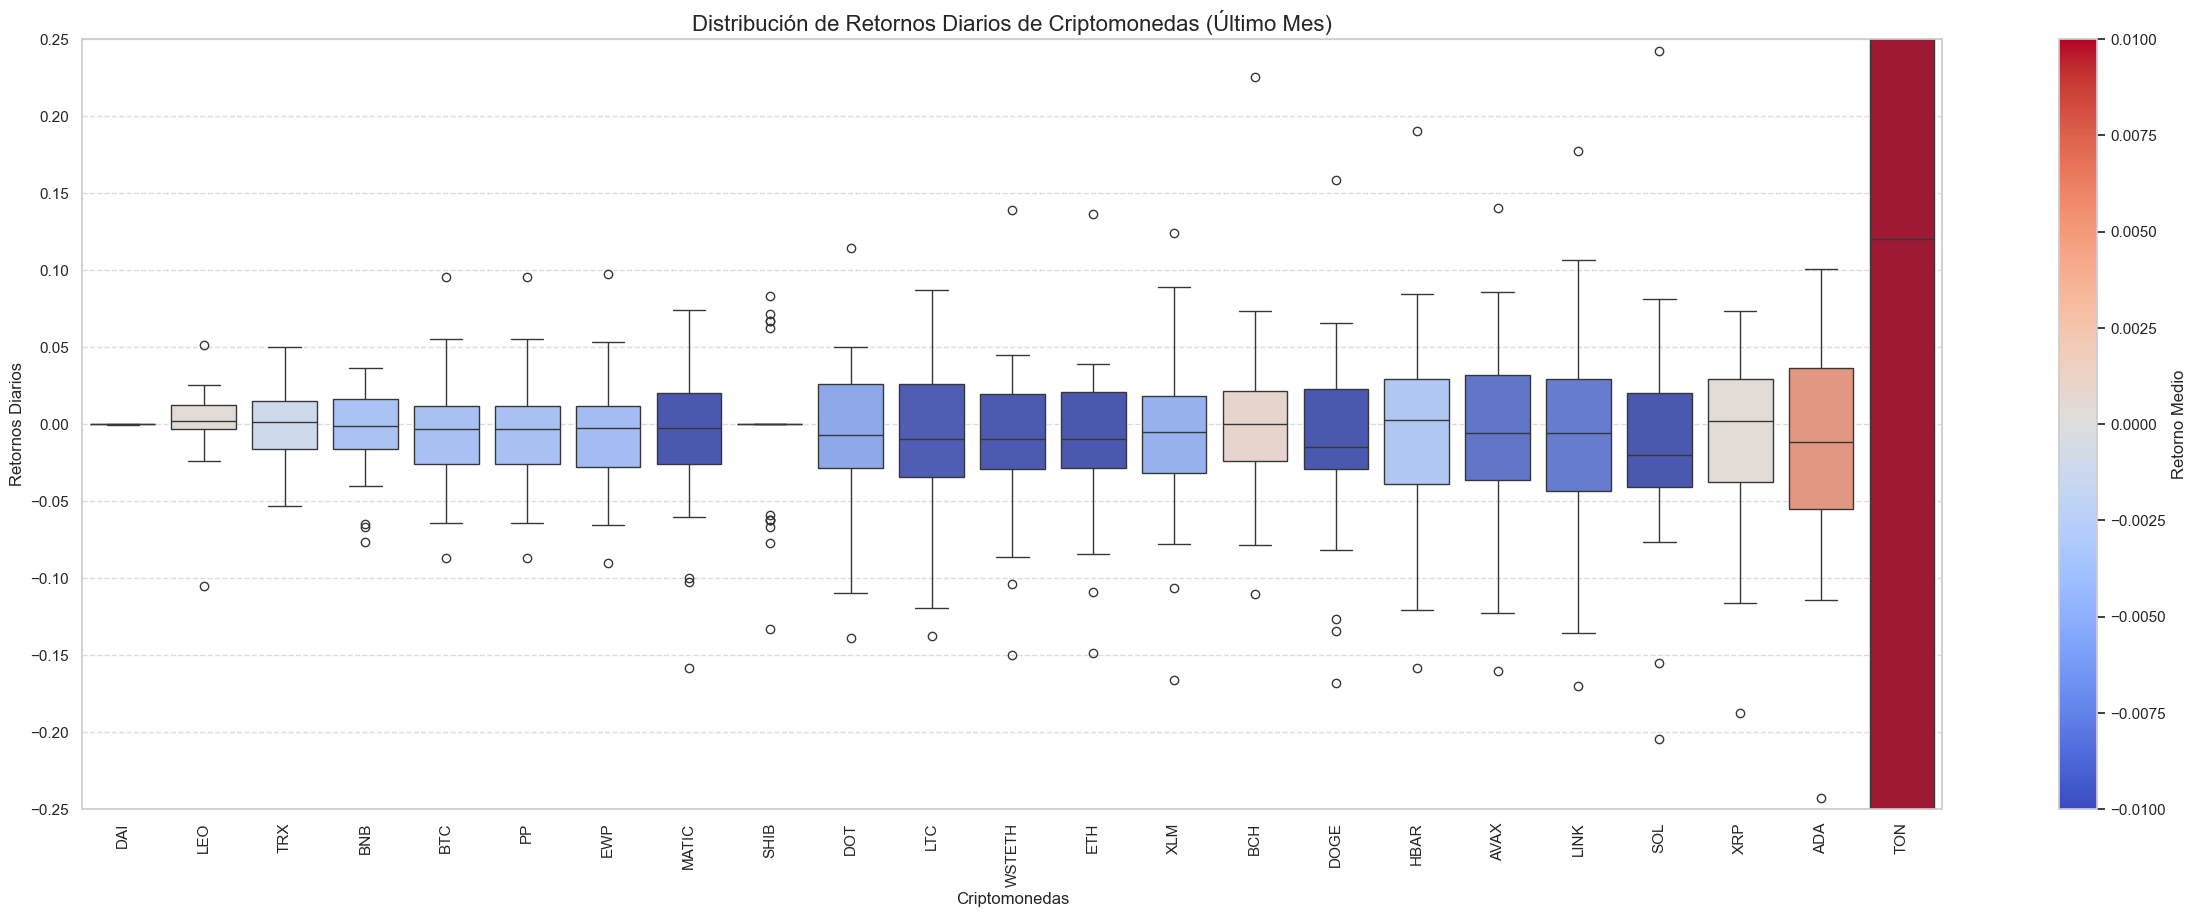

In [43]:

returns = data.pct_change().dropna()            # Calculate returns

# keep from the last 2 years
returns = returns['2025-02-14':]
returns_std = returns.std().sort_values().index  # order them by the standard deviation
returns = returns[returns_std]                   # change the order of the columns

# Calculate the standard deviation and mean of returns
returns_std = returns.std()
mean = returns.mean()



# Create a color palette based on the mean values scaled between -0.03 and 0.03
cmap = sns.color_palette("coolwarm", as_cmap=True)
norm = (mean - (-0.01)) / (0.01 - (-0.01))  # Normalize mean values to [0, 1]
colors = [cmap(val) for val in norm]

from matplotlib.cm import ScalarMappable
# Create a ScalarMappable for the color bar representing the mean values with range fixed from -0.03 to 0.03
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.01, vmax=0.01))
sm.set_array([])



# Adjust the figure size
fig, ax = plt.subplots(figsize=(30, 10))  # Create a figure and an Axes object
sns.set(style='whitegrid')  # Set the style of

# Create the boxplot
sns.boxplot(data=returns, ax=ax, palette=colors)

# Customize the plot
ax.set_title('Distribución de Retornos Diarios de Criptomonedas (Último Mes)', fontsize=16)
ax.set_xlabel('Criptomonedas', fontsize=12)
ax.set_ylabel('Retornos Diarios', fontsize=12)
ax.tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Add more lines in the y-axis
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust the y-axis ticks to be at intervals of 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
# Set the y-axis limits
ax.set_ylim(-1, 1)

# Adjust the y-axis ticks to be at intervals of 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
# Set the y-axis limits
ax.set_ylim(-.25, .25)


cbar = plt.colorbar(sm, ax=ax)
cbar.ax.set_ylabel('Retorno Medio')

# Save the figure as SVG
plt.savefig('svg/05-cryptos-boxplot-1m.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' ensures everything is saved

plt.show()


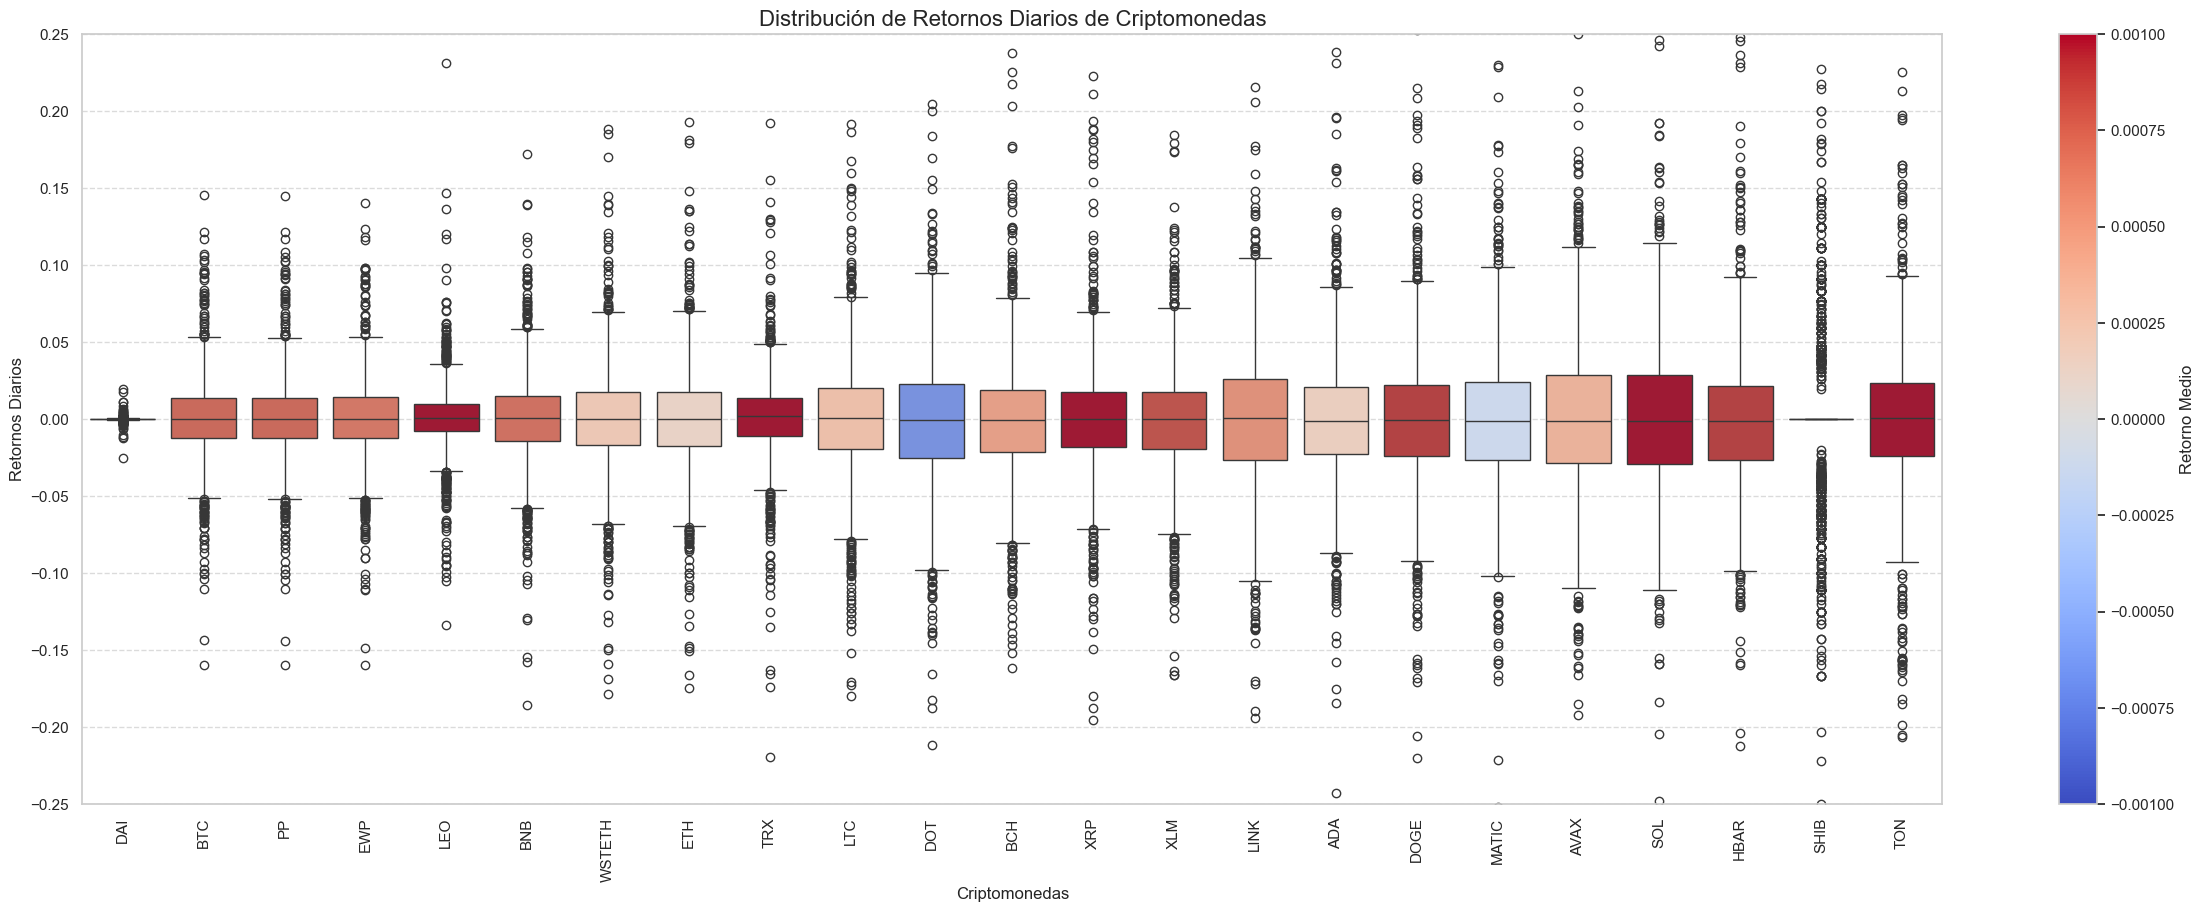

In [41]:
returns = data.pct_change().dropna()            # Calculate returns

returns_std = returns.std().sort_values().index  # order them by the standard deviation
returns = returns[returns_std]                   # change the order of the columns

# Calculate the standard deviation and mean of returns
returns_std = returns.std()
mean = returns.mean()



# Create a color palette based on the mean values scaled between -0.03 and 0.03
cmap = sns.color_palette("coolwarm", as_cmap=True)
norm = (mean - (-0.001)) / (0.001 - (-0.001))  # Normalize mean values to [0, 1]
colors = [cmap(val) for val in norm]

from matplotlib.cm import ScalarMappable
# Create a ScalarMappable for the color bar representing the mean values with range fixed from -0.03 to 0.03
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.001, vmax=0.001))
sm.set_array([])

# Adjust the figure size
fig, ax = plt.subplots(figsize=(30, 10))
sns.set(style='whitegrid')  # Set the style of



# Create the boxplot
sns.boxplot(data=returns, ax=ax, palette=colors)

# Customize the plot
plt.title('Distribución de Retornos Diarios de Criptomonedas', fontsize=16)
plt.xlabel('Criptomonedas', fontsize=12)
plt.ylabel('Retornos Diarios', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# add more lines in the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust the y-axis ticks to be at intervals of 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
# Set the y-axis limits
ax.set_ylim(-.25, .25)


cbar = plt.colorbar(sm, ax=ax)
cbar.ax.set_ylabel('Retorno Medio')

# Save the figure as SVG
plt.savefig('svg/05-cryptos-boxplot.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' ensures everything is saved



plt.show()
